# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hana Asma Nabila
- **Email:** cdcc229d6x2011@student.devacademy.id
- **ID Dicoding:** CDCC229D6X2011

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** "Berapa perbedaan rata-rata jumlah penyewaan sepeda (cnt) antara hari kerja (workingday) dan hari libur (holiday) selama 2011-2012?"
- **Pertanyaan 2:** "Berapa rata-rata jumlah penyewaan sepeda per bulan (cnt) pada tahun 2012, dan bulan apakah yang memiliki performa terendah?"
- **Pertanyaan 3:** "Pada jam berapa yang menunjukkan bahwa permintaan penyewaan sepeda mencapai nilai tertinggi pada hari kerja selama tahun 2012?"

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

## Data Wrangling

### Gathering Data

#### Load tabel "day" dan "hour"

In [2]:
drive.mount('/content/drive')

day_df = pd.read_csv('/content/drive/MyDrive/SI DBS/Analisis Data/day.csv')
day_df.head()

Mounted at /content/drive


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv('/content/drive/MyDrive/SI DBS/Analisis Data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day_df menunjukkan data penyewaan sepeda per hari
- Dataset hour_df menunjukkan data penyewaan sepeda per jam
- Kedua dataset memiliki struktur kolom serupa, dan mencakup informasi lengkap terkait jumlah penyewaan sepeda, kondisi cuaca, dan jenis hari

### Assessing Data

#### Menilai data day_df


In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengoversi kolom dteday ke  tipe data datetime
- Mengubah tipe data fitur kategorikal pada kolom season, yr, mnth, holiday, weekday, workingday, dan wrathersit menjadi category

**Insight:**
- Jumlah data pada day_df telah lengkap, tidak terdapat missing values
- Tidak terdapat duplikasi data
- Tipe data pada kolom dteday terdapat kesalahan, kolom tersebut seharusnya direpresentasikan sebagai tipe data datetime, bukan object
- Tipe data pada kolom season, yr, mnth, holiday, weekday, workingday, dan wrathersit seharusnya direpresentasikan sebagai tipe data kategori, bukan numerik
- Pada ringkasan statistik tidak ditemukan nilai ekstrem yang tidak masuk akal

#### Menilai data hour_df

In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [11]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengoversi kolom dteday ke  tipe data datetime
- Mengubah tipe data fitur kategorikal pada kolom season, yr, mnth, hr, holiday, weekday, workingday, dan wrathersit menjadi category

**Insight:**
- Terjadi inconsistent data representation pada kolom dteday karena direpresentasikan sebagai tipe data object yang seharusnya datetime
- Pada kolom season, yr, mnth, hr, holiday, weekday, workingday, weathersit seharusnya direpresentasikan sebagai tipe data kategori bukan numerik
- Tidak terdapat missing values pada data hour_df
- Tidak ada data yang terduplikasi
- Tidak ditemukan adanya nilai yang tidak masuk akal pada ringkasan statistik

### Cleaning Data

#### Membersihkan data day_df

In [12]:
#Mengonversi kolom dteday menjadi tipe data datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

#Mengonversi kolom season, yr, mnth, holiday, weekday, workingday, dan weathersit menjadi tipe data kategorikal
categorical_columns =["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]

for column in categorical_columns:
  day_df[column] = day_df[column].astype("category")

day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

#### Membersihkan data hour_df

In [13]:
#Mengonversi kolom dteday menjadi tipe data datetime
datetime_columns = ["dteday"]

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

#Mengonversi kolom season, yr, mnth, holiday, weekday, workingday, dan weathersit menjadi tipe data kategorikal
categorical_columns =["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]

for column in categorical_columns:
  hour_df[column] = hour_df[column].astype("category")

hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Tipe data pada kolom dteday  sudah dikonversi ke tipe data datetime
- Tipe data fitur kategorikal pada kolom season, yr, mnth, hr, holiday, weekday, workingday, dan wrathersit menjadi category

## Data Preparation

In [14]:
#Mapping label kategori
day_df['season_label'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

day_df['weather_label'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
})

## Exploratory Data Analysis (EDA)

### Eksplorasi data day_df

In [15]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label
count,731.000000,731,731.0,731.0,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731
unique,NaN,NaN,4.0,2.0,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3
top,NaN,NaN,3.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,Clear
freq,NaN,NaN,188.0,366.0,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,188,463
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,NaN,NaN
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,NaN,NaN
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,NaN,NaN
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,NaN,NaN
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,NaN,NaN
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,NaN,NaN


Mengeksplorasi data day_df tahun 2012

In [16]:
#Data tahun 2012
data_2012_day = day_df[day_df['yr'] == 1]

data_2012_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label
365,366,2012-01-01,1,1,1,0,0,0,1,0.370000,0.375621,0.692500,0.192167,686,1608,2294,Spring,Clear
366,367,2012-01-02,1,1,1,1,1,0,1,0.273043,0.252304,0.381304,0.329665,244,1707,1951,Spring,Clear
367,368,2012-01-03,1,1,1,0,2,1,1,0.150000,0.126275,0.441250,0.365671,89,2147,2236,Spring,Clear
368,369,2012-01-04,1,1,1,0,3,1,2,0.107500,0.119337,0.414583,0.184700,95,2273,2368,Spring,Mist
369,370,2012-01-05,1,1,1,0,4,1,1,0.265833,0.278412,0.524167,0.129987,140,3132,3272,Spring,Clear


In [17]:
data_2012_day.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 365 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   instant        366 non-null    int64         
 1   dteday         366 non-null    datetime64[ns]
 2   season         366 non-null    category      
 3   yr             366 non-null    category      
 4   mnth           366 non-null    category      
 5   holiday        366 non-null    category      
 6   weekday        366 non-null    category      
 7   workingday     366 non-null    category      
 8   weathersit     366 non-null    category      
 9   temp           366 non-null    float64       
 10  atemp          366 non-null    float64       
 11  hum            366 non-null    float64       
 12  windspeed      366 non-null    float64       
 13  casual         366 non-null    int64         
 14  registered     366 non-null    int64         
 15  cnt            366 non-nul

In [18]:
#Rata-rata dan statistik bulanan tahun 2012
monthly_bike_rentals = data_2012_day.groupby('mnth', observed=False)['cnt'].agg(['mean', 'sum', 'min', 'max']).reset_index()

monthly_bike_rentals

,mnth,mean,sum,min,max
0,1,3120.774194,96744,1301,4521
1,2,3556.448276,103137,1529,5062
2,3,5318.548387,164875,3194,8362
3,4,5807.466667,174224,1027,7460
4,5,6318.225806,195865,2843,8294
5,6,6761.000000,202830,4127,8120
6,7,6567.967742,203607,4459,8173
7,8,6919.451613,214503,4549,7865
8,9,7285.766667,218573,4073,8714
9,10,6414.225806,198841,22,8156


In [19]:
#Mengidentifikasi bulan dengan rata-rata penyewaan sepede terendah dan tertinggi tahun 2012

lowest_rentals_month = monthly_bike_rentals.loc[monthly_bike_rentals['mean'].idxmin()]
highest_rentals_month = monthly_bike_rentals.loc[monthly_bike_rentals['mean'].idxmax()]

print("Bulan dengan rata-rata penyewaan sepeda terendah:", lowest_rentals_month['mnth'])
print("Bulan dengan rata-rata penyewaan sepeda tertinggi:", highest_rentals_month['mnth'])

Bulan dengan rata-rata penyewaan sepeda terendah: 1.0
Bulan dengan rata-rata penyewaan sepeda tertinggi: 9.0


In [20]:
monthly_bike_rentals['mean'].describe()

,mean
count,12.000000
mean,5595.784758
std,1392.910679
min,3120.774194
25%,4814.285484
50%,6062.846237
75%,6616.225806
max,7285.766667


Menganalisis penyewaan sepeda pada hari kerja dan hari libur pada data day_df

In [21]:
#Analisis perbandingan hari kerja dan hari libur
bike_rentals_by_day = day_df.groupby('workingday', observed=False)['cnt'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()
bike_rentals_by_day


,workingday,mean,median,std,min,max
0,0,4330.168831,4459.0,2052.141245,605,8714
1,1,4584.820000,4582.0,1878.415583,22,8362


In [22]:
#Selisih rata-rata penyewaan hari kerja dan hari libur
mean_diff = (bike_rentals_by_day.loc[1, 'mean'] - bike_rentals_by_day.loc[0, 'mean'])
print("Selisih rata-rata penyewaan hari kerja dan hari libur:", mean_diff)

Selisih rata-rata penyewaan hari kerja dan hari libur: 254.65116883116843


In [23]:
day_df.groupby('workingday', observed=False)['cnt'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,231.0,4330.168831,2052.141245,605.0,2710.50,4459.0,5907.5,8714.0
1,500.0,4584.820000,1878.415583,22.0,3344.25,4582.0,5987.5,8362.0


**Insight:**
- Berdasarkan ringkasan statistik, dataset day_df terdiri dari 731 data harian penyewaan sepada pada periode 2011-2012. Jumlah minimum penyewaan adalah 22 sepeda dan maksimum mencapai 8714 sepeda, dengan rata-rata penyewaan sepeda per hari sekitar 4504 sepeda. Standar deviasi sebesar 1937 menunjukkan bahwa tingkat penyewaan cukup bervariasi yang mungkin dipengaruhi oleh faktor waktu dan kondisi cuaca
- Pada tahun 2012 terlihat bahwa rata-rata penyewaan sepeda terendah terjadi pada bulan Januari dengan jumlah sekitar 3121 sepeda, dan rata-rata penyewaan tertinggi pada bulan September sekitar 7286 sepeda
- Pada tahun 2012 terlihat bahwa jumlah penyewaan sepeda setiap bulannya meningkat hingga pada pertengahan tahun dan kembali menurun pada akhir tahun
- Berdasarkan hasil agregasi rata-rata penyewaan sepeda pada hari kerja sekitar 4585 sepeda dan pada hari libur sekitar 4330 selama periode 2011-2012
- Terdapat selisih rata-rata penyewaan pada hari kerja dan hari libur sekitar 255 sepeda

### Eksplorasi data hour_df

In [24]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,2.0,12.0,24.0,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,7.0,16.0,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,8734.0,1488.0,730.0,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [25]:
#Data tahun 2012
data_2012_hour = hour_df[hour_df['yr']==1]

data_2012_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
8645,8646,2012-01-01,1,1,1,0,0,0,0,1,0.36,0.3788,0.66,0.0000,5,43,48
8646,8647,2012-01-01,1,1,1,1,0,0,0,1,0.36,0.3485,0.66,0.1343,15,78,93
8647,8648,2012-01-01,1,1,1,2,0,0,0,1,0.32,0.3485,0.76,0.0000,16,59,75
8648,8649,2012-01-01,1,1,1,3,0,0,0,1,0.30,0.3333,0.81,0.0000,11,41,52
8649,8650,2012-01-01,1,1,1,4,0,0,0,1,0.28,0.3030,0.81,0.0896,0,8,8


In [26]:
data_2012_hour.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8734 entries, 8645 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     8734 non-null   int64         
 1   dteday      8734 non-null   datetime64[ns]
 2   season      8734 non-null   category      
 3   yr          8734 non-null   category      
 4   mnth        8734 non-null   category      
 5   hr          8734 non-null   category      
 6   holiday     8734 non-null   category      
 7   weekday     8734 non-null   category      
 8   workingday  8734 non-null   category      
 9   weathersit  8734 non-null   category      
 10  temp        8734 non-null   float64       
 11  atemp       8734 non-null   float64       
 12  hum         8734 non-null   float64       
 13  windspeed   8734 non-null   float64       
 14  casual      8734 non-null   int64         
 15  registered  8734 non-null   int64         
 16  cnt         8734 non-null

Analisis jam penyewaan sepeda tertinggi pada hari kerja tahun 2012

In [27]:
#Filter data hari kerja pada tahun 2012
workingday_2012_hour = data_2012_hour[data_2012_hour['workingday']==1]

#Agregasi per jam
hourly_bike_rentals_2012 = workingday_2012_hour.groupby('hr', observed=False)['cnt'].agg(['mean', 'sum', 'min', 'max']).reset_index()

hourly_bike_rentals_2012

,hr,mean,sum,min,max
0,0,44.188755,11003,3,283
1,1,19.358871,4801,2,92
2,2,9.810484,2433,1,74
3,3,5.489627,1323,1,36
4,4,6.032653,1478,1,16
5,5,32.000000,7936,8,66
6,6,127.508065,31622,17,213
7,7,366.548387,90904,26,596
8,8,604.508065,149918,31,839
9,9,302.391129,74993,23,426


In [28]:
#Jam dengan penyewaan tertinggi pada hari kerja
top_hour_rentals = hourly_bike_rentals_2012.sort_values(by='mean', ascending=False)
top_hour_rentals.head()

,hr,mean,sum,min,max
17,17,656.188755,163391,26,976
18,18,617.000000,153633,26,977
8,8,604.508065,149918,31,839
19,19,437.763052,109003,18,743
16,16,371.542169,92514,13,634


In [29]:
#Jam dengan penyewaan terendah pada hari kerja
lowest_rentals_hour = hourly_bike_rentals_2012.sort_values(by='mean', ascending=True)
lowest_rentals_hour.head()

,hr,mean,sum,min,max
3,3,5.489627,1323,1,36
4,4,6.032653,1478,1,16
2,2,9.810484,2433,1,74
1,1,19.358871,4801,2,92
5,5,32.000000,7936,8,66


**Insight:**
- Berdasarkan ringkasan statistik, dataset hour_df terdiri dari 17.379 data. Rata-rata penyewaan sepeda per jam sekitar 189 sepeda, dengan penyewaan minimum yaitu 1 sepeda dan maksimum 977 sepeda per jam. Standar deviasi cukup tinggi menunjukkan adanya fluktuasi penyewaan antar jam
- Berdasarkan agregasi per jam, penyewaan tertinggi terjadi pada jam 17 atau pada pukul 5 sore dengan rata-rata penyewaan 656 sepeda per jam, dan penyewaan terendah pada dini hari, tepatnya pukul 3 dengan rata-rata sewa 5 sepeda per jam.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

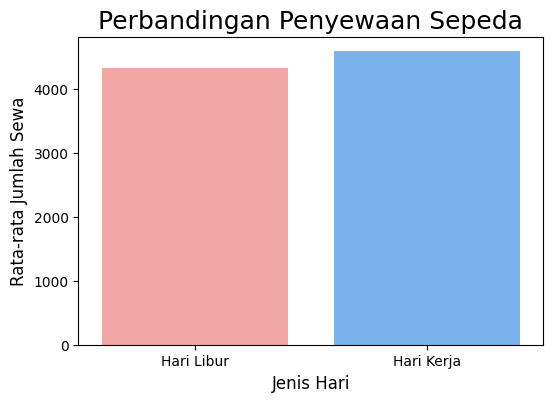

In [30]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=bike_rentals_by_day,
    x='workingday',
    y='mean',
    hue='workingday',
    palette=['#FF9999','#66B2FF'],
    legend=False
)

plt.xticks([0,1], ['Hari Libur', 'Hari Kerja'])
plt.title('Perbandingan Penyewaan Sepeda', fontsize=18)
plt.ylabel('Rata-rata Jumlah Sewa', fontsize=12)
plt.xlabel('Jenis Hari', fontsize=12)

plt.show()

**Insight:**
Berdasarkan visualisasi di atas, terlihat bahwa rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur. Hal ini mengindikasikan bahwa sepeda lebih banyak digunakan pada hari kerja untuk aktivitas pergi/pulang kerja

### Pertanyaan 2:

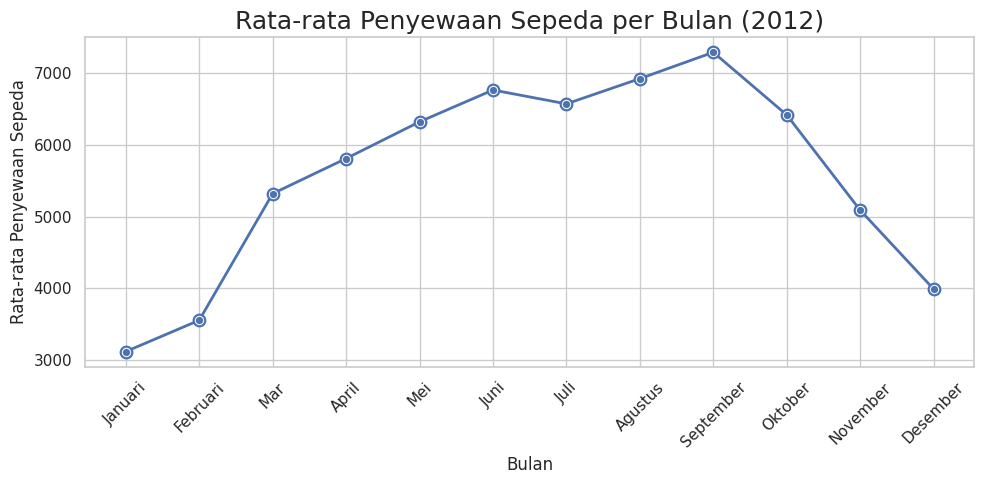

In [31]:
monthly_bike_rentals = monthly_bike_rentals.sort_values('mnth') #Mengurutkan bulan

#Mengubah format bulan dari angka ke nama bulan
nama_bulan = {
    1: 'Januari', 2: 'Februari', 3: 'Mar', 4: 'April', 5: 'Mei', 6: 'Juni',
    7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
}
monthly_bike_rentals['nama_bulan'] = monthly_bike_rentals['mnth'].map(nama_bulan)

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_bike_rentals,
    x='nama_bulan', y='mean',
    marker='o',
    linewidth=2
)

plt.scatter(
    monthly_bike_rentals['nama_bulan'],
    monthly_bike_rentals['mean'], s=80
)

plt.title('Rata-rata Penyewaan Sepeda per Bulan (2012)', fontsize=18)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata Penyewaan Sepeda', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



**Insight:**
- Berdasarkan visualisasi tersebut, dapat dilihat bahwa penyewaan sepada pada tahun 2012 membentuk pola musiman
- Penyewaan sepeda meningkat secara bertahap dari awal tahun pada bulan Januari hingga September
- Setelah bulan september, penyewaan sepeda terjadi penurunan yang cukup signifikan hingga akhir tahun

### Pertanyaan 3:

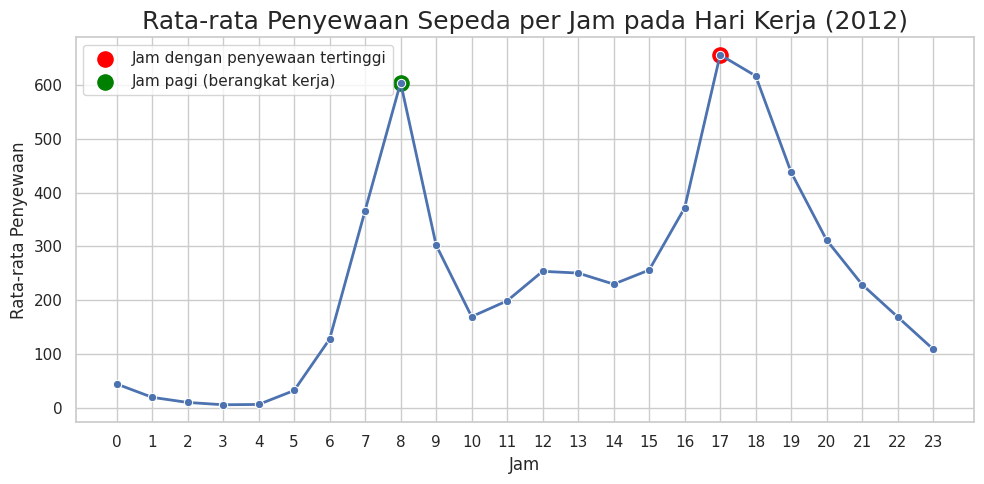

In [32]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_bike_rentals_2012,
    x='hr',
    y='mean',
    marker='o',
    linewidth=2
)

peak = hourly_bike_rentals_2012.loc[hourly_bike_rentals_2012['mean'].idxmax()]

plt.scatter(
    peak['hr'],
    peak['mean'],
    color='red',
    s=120,
    label='Jam dengan penyewaan tertinggi'
)

morning_peak = hourly_bike_rentals_2012[
    hourly_bike_rentals_2012['hr'] == 8
]

plt.scatter(
    morning_peak['hr'],
    morning_peak['mean'],
    color='green',
    s=120,
    label='Jam pagi (berangkat kerja)'
)

plt.title('Rata-rata Penyewaan Sepeda per Jam pada Hari Kerja (2012)', fontsize=18)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()

plt.show()

**Insight:**
- Berdasarkan grafik tersebut, telihat bahwa penyewaan sepeda tertinggi pada jam 17
- Selain itu, terjadi peningkatan yang signifikan pada jam 8 yang menunjukkan jam berangkat kerja
- Pada jam 2-4 jumlah rata-rata penyewaan sangat rendah

## Analisis Lanjutan (Opsional)

### Analisis clustering berdasarkan tingkat penyewaan

Analisis ini bertujuan untuk mengelompokkan hari berdasarkan tingkat penyewaan sepeda (rendah, sedang, dan tinggi) untuk mengidentifikasi pola distribusi permintaan serta memahami faktor-faktor yang memengaruhi tingkat penyewaan seperti musim dan jenis hari

In [33]:
day_df['rental_category'] = pd.qcut(
    day_df['cnt'],
    q=3,
    labels=['Rendah', 'Sedang', 'Tinggi']
)

day_df['rental_category'].value_counts()

,count
rental_category,
Rendah,244
Sedang,244
Tinggi,243


In [34]:
#Menganalisis apakah penyewaan tinggi terjadi di musim tertentu
day_df.groupby(['season_label', 'rental_category'], observed=False)['cnt'].count().unstack()

rental_category,Rendah,Sedang,Tinggi
season_label,,,
Spring,140,33,8
Summer,37,71,76
Fall,13,79,96
Winter,54,61,63


In [35]:
#Menganalisis apakah penyewaan tinggi terjadi pada hari kerja
day_df.groupby(['workingday', 'rental_category'], observed=False)['cnt'].count().unstack()

rental_category,Rendah,Sedang,Tinggi
workingday,,,
0,92,66,73
1,152,178,170


**Insight:**
- Data terbagi menjadi 3 kategori dengan jumlah yang hampir seimbang yaitu rendah 244 hari, sedang 224 hari, dan tinggi 243 hari
- Jumlah kategori penyewaan tinggi terjadi pada season  fall (musim gugur) dengan jumlah 96 hari. Hal ini menunjukkan musim memiliki pengaruh kuat terhadap tingkat penyewaan sepeda
- Penyewaan sepeda lebih tinggi dan lebih konsisten terjadi pada hari kerja

### Analisis Clustering berdasarkan suhu

Analisis ini bertujuan untuk mengelompokkan kondisi suhu ke dalam kategori (rendah, sedang, tinggi) untuk melihat pengaruh suhu terhadap rata-rata jumlah penyewaan sepeda

In [36]:
day_df['temp_category'] = pd.cut(
    day_df['temp'],
    bins=3,
    labels=['Suhu Rendah', 'Suhu Sedang', 'Suhu Tinggi'],
)

day_df.groupby('temp_category', observed=False)['cnt'].mean()

,cnt
temp_category,
Suhu Rendah,2569.005882
Suhu Sedang,4599.000000
Suhu Tinggi,5644.109848


**Insight:**
- Pada suhu tinggi rata-rata penyewaan sepeda memiliki jumlah paling tinggi yaitu sekitar 5644 sepeda dibandingkan dengan pada suhu rendah yang memiliki rata-rata sekitar 2569 sepeda, dan sedang dengan rata-rata 4599 sepeda
- Cuaca yang lebih hangat cenderung mendorong aktivitas bersepeda

### Analisis hubungan antara suhu dan tingkat penyewaan sepeda

Analisis ini bertujuan untuk melihat hubungan antara suhu dan tingkat penyewaan secara lebih detail

In [37]:
pd.crosstab(day_df['temp_category'], day_df['rental_category'])

rental_category,Rendah,Sedang,Tinggi
temp_category,,,
Suhu Rendah,139,21,10
Suhu Sedang,93,103,101
Suhu Tinggi,12,120,132


**Insight:**
- Pada suhu yang rendah, penyewaan sepeda didominasi oleh kategori rendah yaitu 139 hari. Hal ini menunjukkan bahwa kondisi dengan suhu rendah tidak mendukung aktivitas bersepeda
- Pada suhu sedang, penyewaan sepeda cenderung seimbang antara kategori rendah (93 hari), sedang (103 hari), dan tinggi (101 hari). Hal ini menunjukkan bahwa pada kondisi dengan suhu sedang, permintaan mulai meningkat
- Pada suhu yang tinggi, penyewaan sepeda didominasi oleh kategori tinggi yaitu 132 hari. Hal ini menunjukkan bahwa pada kondisi dengan suhu yang tinggi sangat mendukung aktivitas bersepeda
- Hal ini menunjukkan bahwa suhu memiliki pengaruh yang signifikan terhadap distribusi tingkat penyewaan sepeda, di mana semakin tinggi suhu maka semakin besar kemungkinan penyewaan sepeda berada pada kategori tinggi

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata penyewaan sepeda per bulan pada tahun 2012 adalah 5595.784758 atau sekitar 5596 sepeda, dan pada bulan Januari penyewaan sepeda menunjukan performa yang rendah dengan rata-rata penyewaan sepeda sekitar 3121 sepeda.
- **Conclusion pertanyaan 2:** Pada hari kerja rata-rata penyewaan sepeda sekitar 4585 sepeda lebih tinggi dibandingkan pada hari libur yang memiliki rata-rata sekitar 4330 sepeda, dengan selisih penyewaan sekitar 255 sepeda. Hal ini mengindikasikan bahwa banyak orang yang menyewa sepeda sebagai alat transportasi berangkat dan pulang kerja.
- **Conclusion pertanyaan 3:** Pada hari kerja di tahun 2012, penyewaan sepeda tertinggi terjadi pada jam 17 dengan rata-rata sewa 656 sepeda. Pada jam 8 penyewaan sepeda juga menunjukkan jumlah yang cukup tinggi, karena terjadi kenaikan yang signifikan di jam pagi. Hal ini menunjuukan pola penggunaan sepeda terjadi pada jam berangkat dan pulang kerja.

**Rekomendasi Action Item:**
- **Rekomendasi pertanyaan 1:** Agar dapat meningkatkan jumlah penyewaan pada bulan Januari dengan menyusun program promosi yang lebih optimal, dan menyesuaikan kapasitas operasional berdasarkan pola untuk mengindahari over/under supply.
- **Rekomendasi pertanyaan 2:** Mengembangkan strategi promosi atau menerapkan paket khusus untuk hari libur agar meningkatkan pengunaan sepeda, serta mengoptimalkan distribusi sepeda pada hari kerja.
- **Rekomendasi pertanyaan 3:** Menambah ketersediaan sepeda pada jam sibuk (berangkat dan pulang kerja) untuk memenuhi permintaan yang tinggi, dan mengoptimalkan operasional dengan menambah stok sepeda di luar jam sibuk untuk efisiensi

##Export Data

In [38]:
day_df.to_csv("day_clean.csv", index=False)
hour_df.to_csv("hour_clean.csv", index=False)